# Method Comparison: Orthorectified vs. Whole-Field Orthomosaic for Tar Spot Disease Representation (PPAC-B3, 2024)

This notebook evaluates which VI-extraction method (`orthorectified` vs `whole`-field
orthomosaic), and which soil-handling option (`SOIL` raw vs masked), produces vegetation
index values that better represent the tar spot disease situation.

Sections:
1. Data loading & structuring
2. Method concordance/agreement (orthorectified vs whole)
3. Univariate VI-severity relationship strength (mixed models)
4. Multivariate predictive comparison (RF / PLSR / Ridge, GroupKFold CV)
5. Temporal / disease-progression analysis
6. Feature importance comparison

## Section 0 — Setup & Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, wilcoxon, permutation_test
import statsmodels.formula.api as smf
from statsmodels.graphics.agreement import mean_diff_plot
import pingouin as pg
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_excel("../combined_vi_stats_with_disease_PPAC-B3.xlsx")
df["DATE"] = pd.to_datetime(df["DATE"], format="%m%d%Y").dt.strftime("%m/%d/%Y")

# 08/03/2024 has no SEVERITY at all: the source disease evaluation file is missing the
# "tar7" (Time=7, August 3) column entirely, so there is no ground-truth rating for that
# flight date. Drop these rows for all severity-based analyses below.
df_sev = df.dropna(subset=["SEVERITY"]).reset_index(drop=True)
print("Full data:", df.shape, "| Severity-complete data:", df_sev.shape)
assert df_sev.shape[0] == 3780

vi_mean_std_cols = [c for c in df.columns if c.endswith(("_MEAN", "_STD"))]
vi_all_cols = [c for c in df.columns if c.endswith(("_MEAN", "_STD", "_MIN", "_MAX"))]
methods = ["orthorectified", "whole"]
soils = ["YES", "NO"]

print(f"{len(vi_mean_std_cols)} mean VI columns:", vi_mean_std_cols)

Full data: (4320, 56) | Severity-complete data: (3780, 56)
24 mean VI columns: ['NDVI_MEAN', 'NDVI_STD', 'NDRE_MEAN', 'NDRE_STD', 'EXG_MEAN', 'EXG_STD', 'PSRI_MEAN', 'PSRI_STD', 'RDVI_MEAN', 'RDVI_STD', 'MCARI2_MEAN', 'MCARI2_STD', 'RED_MEAN', 'RED_STD', 'GREEN_MEAN', 'GREEN_STD', 'BLUE_MEAN', 'BLUE_STD', 'REDEDGE_MEAN', 'REDEDGE_STD', 'NIR_MEAN', 'NIR_STD', 'OSAVI_MEAN', 'OSAVI_STD']


## Section 1 — Data Structuring for METHOD x SOIL Comparison

In [4]:
# Wide table: one row per (DATE, POINT, SOIL), with paired orthorectified/whole VI values
wide = df_sev.pivot_table(index=["DATE", "POINT", "SOIL"], columns="METHOD", values=vi_mean_std_cols)
wide.columns = [f"{vi}_{method}" for vi, method in wide.columns]
wide = wide.reset_index()
print(wide.shape)
wide.head()

(1890, 51)


,DATE,POINT,SOIL,BLUE_MEAN_orthorectified,BLUE_MEAN_whole,BLUE_STD_orthorectified,BLUE_STD_whole,EXG_MEAN_orthorectified,EXG_MEAN_whole,EXG_STD_orthorectified,...,RDVI_STD_orthorectified,RDVI_STD_whole,REDEDGE_MEAN_orthorectified,REDEDGE_MEAN_whole,REDEDGE_STD_orthorectified,REDEDGE_STD_whole,RED_MEAN_orthorectified,RED_MEAN_whole,RED_STD_orthorectified,RED_STD_whole
0,06/17/2024,1,NO,0.047098,0.048181,0.011170,0.010251,0.034338,0.031471,0.022872,...,0.088796,0.084276,0.124490,0.125336,0.021797,0.020113,0.072813,0.075606,0.022225,0.021442
1,06/17/2024,1,YES,0.055018,0.056589,0.012113,0.011100,0.011946,0.010627,0.021857,...,0.087991,0.080028,0.122292,0.125185,0.020743,0.018091,0.092109,0.095468,0.024506,0.023254
2,06/17/2024,2,NO,0.047235,0.048245,0.011718,0.011352,0.034780,0.033796,0.024729,...,0.090920,0.090070,0.128007,0.129992,0.022632,0.021994,0.075006,0.077550,0.024160,0.024145
3,06/17/2024,2,YES,0.054894,0.056395,0.012667,0.012044,0.014002,0.013308,0.024013,...,0.092301,0.088018,0.127784,0.130849,0.021670,0.019876,0.094157,0.097756,0.026745,0.026145
4,06/17/2024,3,NO,0.046544,0.046923,0.011876,0.010720,0.034638,0.033380,0.025172,...,0.094069,0.088356,0.126490,0.126702,0.023079,0.020520,0.073198,0.074486,0.024351,0.022936


In [5]:
# Long data per (METHOD, SOIL) combo, used for Sections 3-6
combo_data = {}
for method in methods:
    for soil in soils:
        sub = df_sev[(df_sev["METHOD"] == method) & (df_sev["SOIL"] == soil)]
        combo_data[(method, soil)] = sub[["POINT", "DATE"] + vi_mean_std_cols + ["SEVERITY"]].reset_index(drop=True)
        print(method, soil, combo_data[(method, soil)].shape)

orthorectified YES (945, 27)
orthorectified NO (945, 27)
whole YES (945, 27)
whole NO (945, 27)


**Leakage note**: each `POINT` (1-135) appears 7 times within every (METHOD, SOIL) combo
(once per remaining flight date). All cross-validation and grouping below uses
`groups=POINT`, so a plot's repeated-date observations never span both the train and
test folds.

## Section 2 — Method Concordance/Agreement (orthorectified vs whole)

In [8]:
def lin_ccc(x, y):
    """Lin's concordance correlation coefficient."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(), y.var()
    sxy = np.mean((x - mx) * (y - my))
    return 2 * sxy / (vx + vy + (mx - my) ** 2)


concordance_rows = []
for soil in soils:
    sub_wide = wide[wide["SOIL"] == soil]
    for vi in vi_mean_std_cols:
        col_o, col_w = f"{vi}_orthorectified", f"{vi}_whole"
        x = sub_wide[col_o].to_numpy()
        y = sub_wide[col_w].to_numpy()
        mask = ~(np.isnan(x) | np.isnan(y))
        x, y = x[mask], y[mask]

        ccc = lin_ccc(x, y)

        long_df = pd.DataFrame({
            "subject": np.tile(np.arange(len(x)), 2),
            "rater": ["orthorectified"] * len(x) + ["whole"] * len(x),
            "value": np.concatenate([x, y]),
        })

        rho, _ = spearmanr(x, y)

        diff = y - x
        mean_bias = diff.mean()
        loa_width = 2 * 1.96 * diff.std()

        concordance_rows.append({
            "VI": vi, "SOIL": soil, "CCC": ccc,
            "Spearman_r": rho, "Mean_bias": mean_bias, "LoA_width": loa_width,
        })

concordance_df = pd.DataFrame(concordance_rows).sort_values(["SOIL", "CCC"]).reset_index(drop=True)
concordance_df[concordance_df["SOIL"] == "NO"]

,VI,SOIL,CCC,Spearman_r,Mean_bias,LoA_width
0,NIR_STD,NO,0.429408,0.788160,-0.011199,0.081367
1,BLUE_STD,NO,0.633168,0.923452,-0.001633,0.002658
2,REDEDGE_STD,NO,0.649200,0.859799,-0.004135,0.015039
3,EXG_STD,NO,0.708114,0.879804,-0.002725,0.007172
4,GREEN_STD,NO,0.734662,0.909081,-0.002189,0.005556
5,GREEN_MEAN,NO,0.786353,0.918548,-0.002295,0.006699
6,RDVI_STD,NO,0.796508,0.842105,-0.006782,0.039874
7,REDEDGE_MEAN,NO,0.811225,0.878705,-0.002558,0.019643
8,MCARI2_STD,NO,0.834608,0.865235,-0.005390,0.025142
9,NDRE_STD,NO,0.884107,0.961781,-0.006262,0.012277


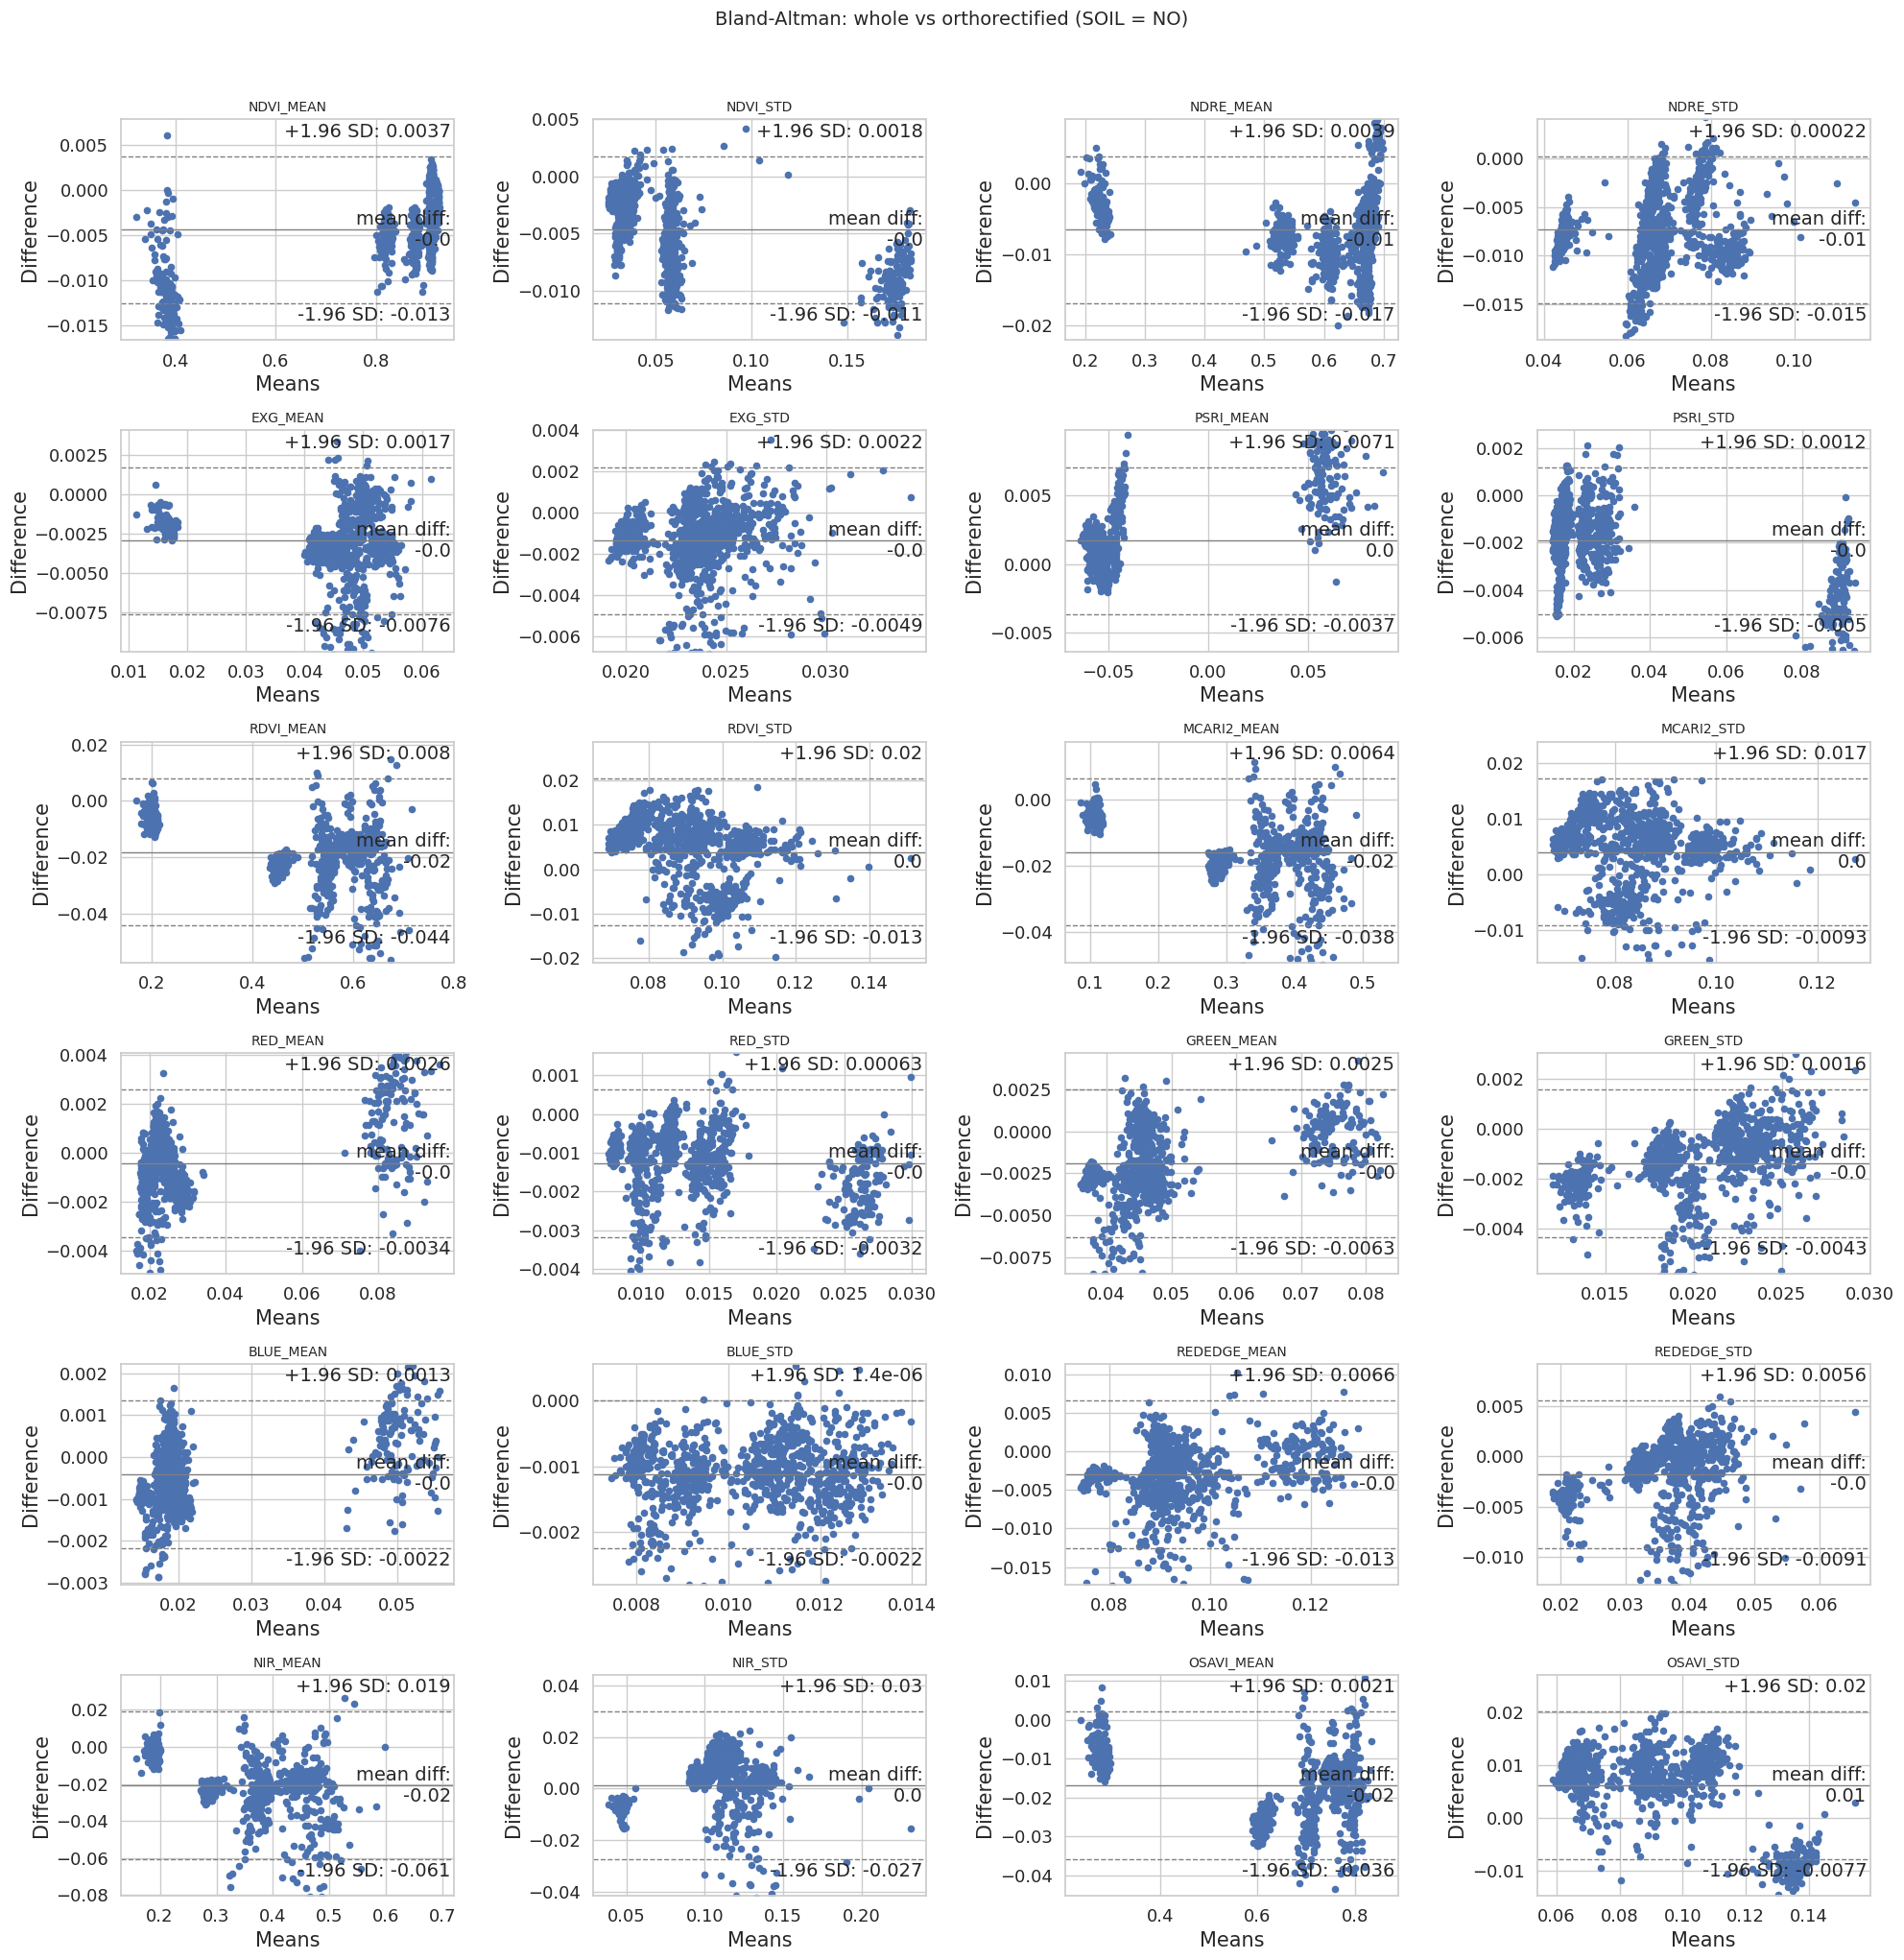

In [6]:
# Bland-Altman plots (whole - orthorectified) for SOIL=NO
sub_wide = wide[wide["SOIL"] == "YES"]
fig, axes = plt.subplots(6, 4, figsize=(20, 20))
for ax, vi in zip(axes.flat, vi_mean_std_cols):
    x = sub_wide[f"{vi}_orthorectified"].to_numpy()
    y = sub_wide[f"{vi}_whole"].to_numpy()
    mask = ~(np.isnan(x) | np.isnan(y))
    mean_diff_plot(y[mask], x[mask], ax=ax)
    ax.set_title(vi, fontsize=10)
for ax in axes.flat[len(vi_mean_std_cols):]:
    ax.axis("off")
fig.suptitle("Bland-Altman: whole vs orthorectified (SOIL = NO)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Section 3 — Univariate VI-Severity Relationship Strength

**Note**: `MixedLM` may print `ConvergenceWarning`s for some VIs (the random-intercept
variance estimate sits near the boundary of the parameter space). This is a common,
largely benign occurrence with unbalanced/near-zero variance components and does not
materially affect the fixed-effect (slope/interaction) estimates used below.

In [7]:
mixed_rows = []
for soil in soils:
    for vi in vi_mean_std_cols:
        sub = df_sev.loc[df_sev["SOIL"] == soil, ["POINT", "SEVERITY", "METHOD", vi]].dropna()
        sub = sub.rename(columns={vi: "VI"})
        # z-score the VI predictor: puts all VIs (very different raw scales, e.g. EXG ~0.01-0.09
        # vs PSRI ~ -0.2-0.1) on a comparable footing and avoids MixedLM convergence failures
        # caused by scale mismatch between the predictor and SEVERITY (0-6).
        sub["VI"] = (sub["VI"] - sub["VI"].mean()) / sub["VI"].std()

        model = smf.mixedlm("SEVERITY ~ VI * C(METHOD)", data=sub, groups=sub["POINT"], re_formula="~1")
        fit = model.fit()

        params, pvalues = fit.params, fit.pvalues
        interaction_terms = [p for p in params.index if p.startswith("VI:")]
        interaction_term = interaction_terms[0]

        slope_ortho = params["VI"]
        slope_whole = params["VI"] + params[interaction_term]

        mixed_rows.append({
            "VI": vi, "SOIL": soil,
            "interaction_p": pvalues[interaction_term],
            "slope_per_SD_orthorectified": slope_ortho,
            "slope_per_SD_whole": slope_whole,
            "loglik": fit.llf,
        })

mixed_df = pd.DataFrame(mixed_rows).sort_values(["SOIL", "interaction_p"]).reset_index(drop=True)
mixed_df

/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/

,VI,SOIL,interaction_p,slope_per_SD_orthorectified,slope_per_SD_whole,loglik
0,REDEDGE_STD,NO,0.003907,0.177807,0.375508,-3283.267887
1,GREEN_STD,NO,0.232969,0.342220,0.420428,-3250.517579
2,NDVI_STD,NO,0.445170,-0.013577,-0.062522,-3315.145684
3,NDRE_STD,NO,0.527610,0.213334,0.254253,-3289.734657
4,EXG_STD,NO,0.594242,0.160934,0.124895,-3306.917605
5,OSAVI_STD,NO,0.606981,0.029898,-0.003141,-3315.902682
6,RED_STD,NO,0.706734,-0.026512,-0.050969,-3315.350550
7,PSRI_STD,NO,0.711942,-0.010746,-0.034446,-3315.820254
8,RDVI_STD,NO,0.719007,-0.106417,-0.082985,-3311.754211
9,EXG_MEAN,NO,0.738958,0.014008,0.035456,-3315.782849


In [8]:
fit.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
================================================================
Model:                MixedLM   Dependent Variable:   SEVERITY  
No. Observations:     1890      Method:               REML      
No. Groups:           135       Scale:                1.9374    
Min. group size:      14        Log-Likelihood:       -3315.9027
Max. group size:      14        Converged:            No        
Mean group size:      14.0                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.644    0.046 14.052 0.000  0.554  0.734
C(METHOD)[T.whole]     0.002    0.064  0.031 0.975 -0.124  0.128
VI                     0.030    0.046  0.657 0.511 -0.059  0.119
VI:C(METHOD)[T.whole] -0.033    0.064 -0.514 0.607 -0.159  0.093
Group Var              0.005                                    
================================================================

"""

In [9]:

# Joint mixed model: all VIs together (one model per SOIL, with METHOD interaction)
from sklearn.inspection import permutation_importance

joint_mixed_rows = []
joint_fitted_models = {}  # (soil, "mixed") -> fitted model

for soil in soils:
    sub = df_sev.loc[df_sev["SOIL"] == soil, ["POINT", "SEVERITY", "METHOD"] + vi_mean_std_cols].dropna()
    
    # Standardize all VIs
    sub_std = sub.copy()
    for vi in vi_mean_std_cols:
        sub_std[vi] = (sub[vi] - sub[vi].mean()) / sub[vi].std()
    
    # Build formula: SEVERITY ~ VI1 + VI2 + ... + VI13 + C(METHOD) + VI1:C(METHOD) + ...
    vi_cols_str = " + ".join(vi_mean_std_cols)
    interactions_str = " + ".join([f"{vi}:C(METHOD)" for vi in vi_mean_std_cols])
    formula = f"SEVERITY ~ {vi_cols_str} + C(METHOD) + {interactions_str}"
    
    # Fit joint mixed model
    model = smf.mixedlm(formula, data=sub_std, groups=sub_std["POINT"], re_formula="~1")
    fit = model.fit()
    joint_fitted_models[(soil, "mixed")] = fit
    
    # Extract coefficients and p-values for each VI (main effect)
    params, pvalues, conf_int = fit.params, fit.pvalues, fit.conf_int()
    
    for vi in vi_mean_std_cols:
        coef = params[vi] if vi in params.index else np.nan
        pval = pvalues[vi] if vi in pvalues.index else np.nan
        ci_lower = conf_int.loc[vi, 0] if vi in conf_int.index else np.nan
        ci_upper = conf_int.loc[vi, 1] if vi in conf_int.index else np.nan
        
        # Check for interaction term
        interaction_term = f"{vi}:C(METHOD)[T.whole]"
        interaction_coef = params[interaction_term] if interaction_term in params.index else np.nan
        interaction_pval = pvalues[interaction_term] if interaction_term in pvalues.index else np.nan
        
        joint_mixed_rows.append({
            "SOIL": soil, "VI": vi,
            "coef": coef,
            "p_value": pval,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
            "interaction_coef": interaction_coef,
            "interaction_p": interaction_pval,
        })

joint_mixed_df = pd.DataFrame(joint_mixed_rows).sort_values(["SOIL", "p_value"]).reset_index(drop=True)
print("Joint mixed model (all VIs together) — main effects by VI:")
print(joint_mixed_df)


/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/base/model.py:607: Conve

Joint mixed model (all VIs together) — main effects by VI:
   SOIL            VI        coef       p_value       ci_lower       ci_upper  \
0    NO     NDRE_MEAN  -25.740967  2.477717e-29     -30.227909     -21.254024   
1    NO    OSAVI_MEAN -243.669357  2.468839e-28    -286.931352    -200.407363   
2    NO  REDEDGE_MEAN   -4.993353  3.483320e-28      -5.882387      -4.104319   
3    NO    MCARI2_STD   -3.568951  1.381640e-13      -4.514468      -2.623434   
4    NO     RDVI_MEAN  472.459632  8.232193e-13     343.079478     601.839787   
5    NO     NDVI_MEAN   51.644079  1.465399e-12      37.342798      65.945359   
6    NO      NIR_MEAN -141.735254  9.419487e-12    -182.497060    -100.973448   
7    NO      PSRI_STD   -2.402348  3.578500e-08      -3.256813      -1.547883   
8    NO     OSAVI_STD    6.511575  1.221777e-06       3.881266       9.141884   
9    NO   MCARI2_MEAN  -88.735553  1.296871e-05    -128.619329     -48.851776   
10   NO      BLUE_STD   -0.621795  2.613108e-05   

/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [10]:

# Permutation importance: measure each VI's marginal contribution to prediction within joint model
# (approximated via linear model predictions, controlling for collinearity)

from sklearn.linear_model import Ridge

perm_importance_rows = []

for soil in soils:
    sub = df_sev.loc[df_sev["SOIL"] == soil, ["POINT", "SEVERITY", "METHOD"] + vi_mean_std_cols].dropna()
    
    # Standardize
    sub_std = sub.copy()
    for vi in vi_mean_std_cols:
        sub_std[vi] = (sub[vi] - sub[vi].mean()) / sub[vi].std()
    
    # Build X, y for Ridge regression (with METHOD as dummy)
    sub_std["METHOD_whole"] = (sub_std["METHOD"] == "whole").astype(int)
    X = sub_std[vi_mean_std_cols + ["METHOD_whole"]].values
    y = sub_std["SEVERITY"].values
    
    # Fit Ridge to handle collinearity
    ridge = Ridge(alpha=1.0)
    ridge.fit(X, y)
    
    # Baseline R2
    pred_baseline = ridge.predict(X)
    r2_baseline = r2_score(y, pred_baseline)
    
    # Permutation importance: for each VI, shuffle it and measure R2 drop
    for i, vi in enumerate(vi_mean_std_cols):
        X_perm = X.copy()
        X_perm[:, i] = np.random.permutation(X_perm[:, i])
        pred_perm = ridge.predict(X_perm)
        r2_perm = r2_score(y, pred_perm)
        importance = max(0, r2_baseline - r2_perm)  # R2 drop when VI is shuffled
        
        perm_importance_rows.append({
            "SOIL": soil, "VI": vi,
            "permutation_importance": importance,
        })

perm_importance_df = pd.DataFrame(perm_importance_rows).sort_values(["SOIL", "permutation_importance"], ascending=[True, False])
print("\nPermutation importance (R2 drop when VI shuffled) — joint Ridge model:")
print(perm_importance_df)

# Merge with joint_mixed_df for side-by-side view
joint_mixed_with_perm = joint_mixed_df.merge(
    perm_importance_df, 
    on=["SOIL", "VI"]
).sort_values(["SOIL", "permutation_importance"], ascending=[True, False])
print("\nCombined: mixed-model coefficients + permutation importance:")
print(joint_mixed_with_perm[["SOIL", "VI", "coef", "p_value", "permutation_importance"]])



Permutation importance (R2 drop when VI shuffled) — joint Ridge model:
   SOIL            VI  permutation_importance
44   NO      NIR_MEAN               16.136510
25   NO      NDVI_STD               12.215847
26   NO     NDRE_MEAN               11.574033
47   NO     OSAVI_STD               10.291620
30   NO     PSRI_MEAN                9.833085
33   NO      RDVI_STD                5.722009
35   NO    MCARI2_STD                4.733163
46   NO    OSAVI_MEAN                3.475057
36   NO      RED_MEAN                1.374250
34   NO   MCARI2_MEAN                1.327526
39   NO     GREEN_STD                1.323502
45   NO       NIR_STD                0.892912
29   NO       EXG_STD                0.876064
28   NO      EXG_MEAN                0.740651
41   NO      BLUE_STD                0.380463
37   NO       RED_STD                0.378915
24   NO     NDVI_MEAN                0.216463
31   NO      PSRI_STD                0.215851
32   NO     RDVI_MEAN                0.177443
42   NO 

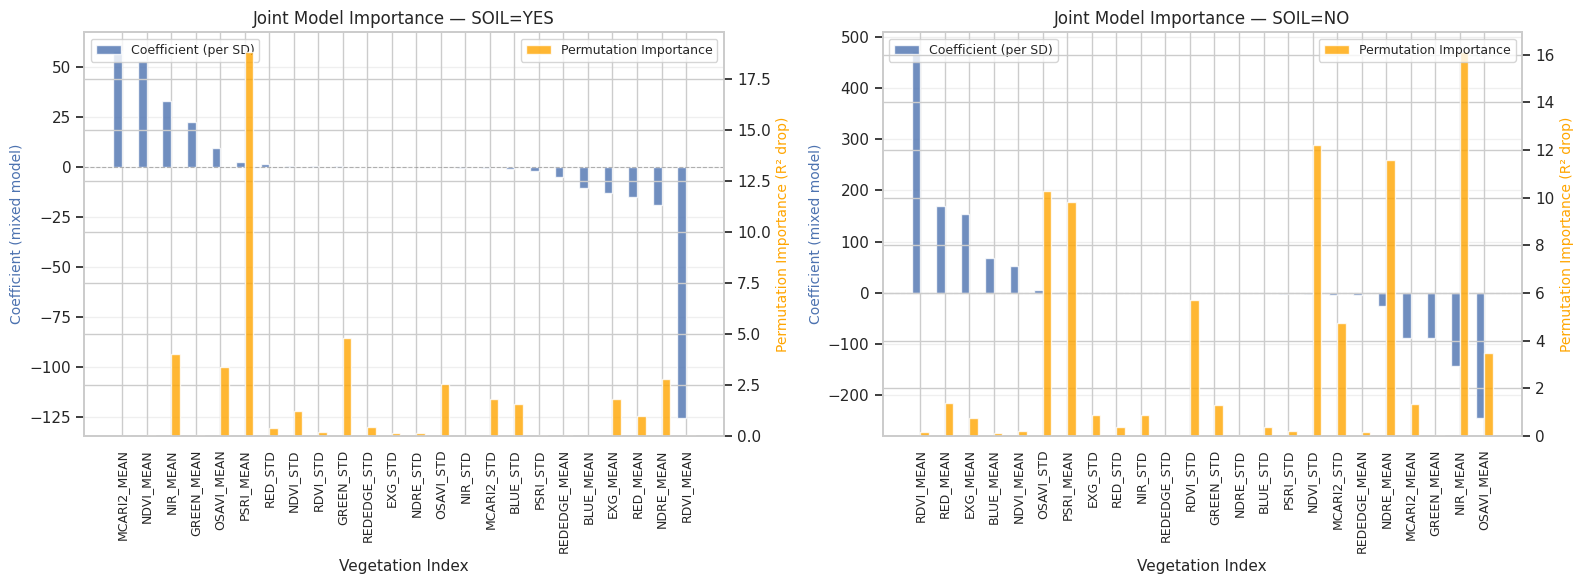

In [11]:

# Visualization: coefficients vs permutation importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, soil in zip(axes, soils):
    sub_data = joint_mixed_with_perm[joint_mixed_with_perm["SOIL"] == soil].sort_values("coef", ascending=False)
    
    x = np.arange(len(sub_data))
    width = 0.35
    
    ax.bar(x - width/2, sub_data["coef"], width, label="Coefficient (per SD)", alpha=0.8)
    ax_twin = ax.twinx()
    ax_twin.bar(x + width/2, sub_data["permutation_importance"], width, label="Permutation Importance", alpha=0.8, color="orange")
    
    ax.set_xlabel("Vegetation Index", fontsize=11)
    ax.set_ylabel("Coefficient (mixed model)", fontsize=10, color="C0")
    ax_twin.set_ylabel("Permutation Importance (R² drop)", fontsize=10, color="orange")
    ax.set_title(f"Joint Model Importance — SOIL={soil}", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(sub_data["VI"], rotation=90, fontsize=9)
    ax.axhline(0, color="k", lw=0.8, linestyle="--", alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)
    ax_twin.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [12]:
# Per-date Spearman correlation (VI vs SEVERITY across 135 points), Fisher-z averaged across dates
spearman_rows = []
for (method, soil), sub in combo_data.items():
    for vi in vi_mean_std_cols:
        rhos = []
        for _, g in sub.groupby("DATE"):
            r, _ = spearmanr(g[vi], g["SEVERITY"])
            rhos.append(r)
        z = np.arctanh(np.clip(rhos, -0.999, 0.999))
        mean_rho = np.tanh(np.nanmean(z))
        spearman_rows.append({"METHOD": method, "SOIL": soil, "VI": vi, "mean_spearman": mean_rho})

spearman_df = pd.DataFrame(spearman_rows)

# Merge mean Spearman rho's into the mixed-model comparison table
comparison_df = mixed_df.copy()
for method in methods:
    pivot = spearman_df[spearman_df["METHOD"] == method].set_index(["VI", "SOIL"])["mean_spearman"]
    comparison_df[f"mean_spearman_{method}"] = comparison_df.set_index(["VI", "SOIL"]).index.map(pivot)

comparison_df

/tmp/ipykernel_91268/2179483180.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g[vi], g["SEVERITY"])


,VI,SOIL,interaction_p,slope_per_SD_orthorectified,slope_per_SD_whole,loglik,mean_spearman_orthorectified,mean_spearman_whole
0,REDEDGE_STD,NO,0.003907,0.177807,0.375508,-3283.267887,-0.049768,-0.014232
1,GREEN_STD,NO,0.232969,0.342220,0.420428,-3250.517579,-0.037000,-0.006120
2,NDVI_STD,NO,0.445170,-0.013577,-0.062522,-3315.145684,-0.043912,-0.075373
3,NDRE_STD,NO,0.527610,0.213334,0.254253,-3289.734657,-0.045111,-0.043346
4,EXG_STD,NO,0.594242,0.160934,0.124895,-3306.917605,-0.027557,-0.009774
5,OSAVI_STD,NO,0.606981,0.029898,-0.003141,-3315.902682,-0.041955,-0.086471
6,RED_STD,NO,0.706734,-0.026512,-0.050969,-3315.350550,-0.074893,-0.036352
7,PSRI_STD,NO,0.711942,-0.010746,-0.034446,-3315.820254,-0.000657,-0.057305
8,RDVI_STD,NO,0.719007,-0.106417,-0.082985,-3311.754211,-0.049707,-0.063421
9,EXG_MEAN,NO,0.738958,0.014008,0.035456,-3315.782849,0.010008,0.023878


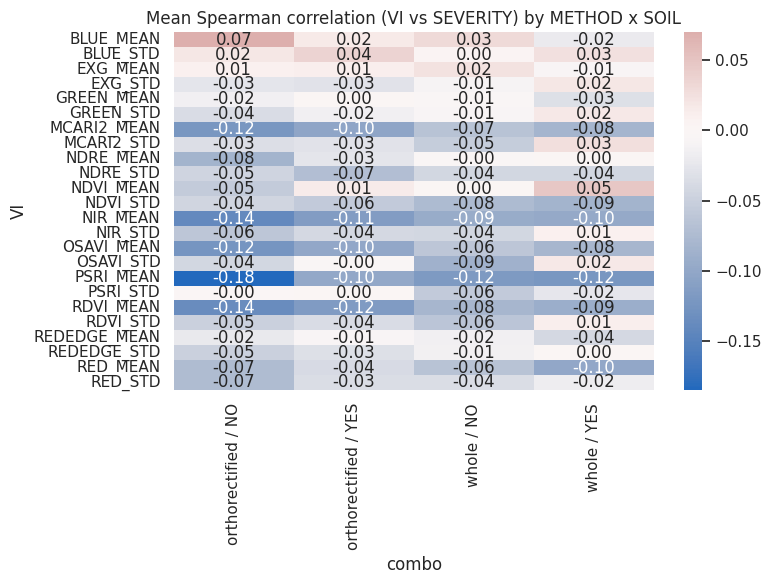

In [13]:
# Heatmap of mean Spearman rho by VI x (METHOD, SOIL)
heat = spearman_df.copy()
heat["combo"] = heat["METHOD"] + " / " + heat["SOIL"]
heat_pivot = heat.pivot(index="VI", columns="combo", values="mean_spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(heat_pivot, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Mean Spearman correlation (VI vs SEVERITY) by METHOD x SOIL")
plt.tight_layout()
plt.show()

## Section 4 — Multivariate Predictive Comparison

**RF vs PLSR vs Ridge tradeoff**: `RandomForestRegressor` matches the teammate's approach
and can capture non-linear/interaction effects, but its importances can be unstable and
biased toward correlated features (the 13 VIs here are highly collinear). `PLSRegression`
projects the predictors onto a small number of latent components that maximize covariance
with the response, handling collinearity by construction and giving more stable, interpretable
loadings/VIP scores. `RidgeCV` is included as a simple linear baseline.

In [14]:
cv = GroupKFold(n_splits=5)

def make_models():
    return {
        "RF": RandomForestRegressor(n_estimators=500, random_state=42),
        "PLSR": Pipeline([("scaler", StandardScaler()), ("pls", PLSRegression(n_components=4))]),
        "Ridge": Pipeline([("scaler", StandardScaler()), ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 13)))]),
    }

cv_rows = []
fitted_models = {}  # (method, soil, model_name) -> list of fitted models, one per fold

for (method, soil), sub in combo_data.items():
    X = sub[vi_mean_std_cols].to_numpy()
    y = sub["SEVERITY"].to_numpy()
    groups = sub["POINT"].to_numpy()
    models = make_models()

    for model_name, model in models.items():
        fitted_models[(method, soil, model_name)] = []
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
            m = clone(model)
            m.fit(X[train_idx], y[train_idx])
            pred = m.predict(X[test_idx]).ravel()

            cv_rows.append({
                "METHOD": method, "SOIL": soil, "MODEL": model_name, "FOLD": fold_idx,
                "R2": r2_score(y[test_idx], pred),
                "RMSE": np.sqrt(mean_squared_error(y[test_idx], pred)),
                "MAE": mean_absolute_error(y[test_idx], pred),
            })
            fitted_models[(method, soil, model_name)].append(m)

cv_df = pd.DataFrame(cv_rows)
cv_df.groupby(["SOIL", "MODEL", "METHOD"])[["R2", "RMSE", "MAE"]].agg(["mean", "std"])

R2                RMSE                 MAE  \
                               mean       std      mean       std      mean   
SOIL MODEL METHOD                                                             
NO   PLSR  orthorectified  0.707756  0.026848  0.750750  0.037998  0.588298   
           whole           0.661902  0.042441  0.807040  0.055993  0.608497   
     RF    orthorectified  0.896416  0.125349  0.395971  0.218641  0.130955   
           whole           0.894463  0.117964  0.407120  0.202670  0.138262   
     Ridge orthorectified  0.887501  0.073699  0.448836  0.125616  0.265827   
           whole           0.860354  0.077225  0.504533  0.120913  0.292621   
YES  PLSR  orthorectified  0.687711  0.023596  0.776602  0.041288  0.603740   
           whole           0.701375  0.019087  0.759169  0.025159  0.580184   
     RF    orthorectified  0.939612  0.033103  0.330803  0.083415  0.116698   
           whole           0.946075  0.014338  0.319763  0.036853  0.115106   
     Ridge orthorectified  0.931590  0.014788  0.361325  0.041371  0.219253   
           whole           0.908913  0.023017  0.416674  0.050549  0.250145   

                                     
                                std  
SOIL MODEL METHOD                    
NO   PLSR  orthorectified  0.025470  
           whole           0.032146  
     RF    orthorectified  0.052114  
           whole           0.051553  
     Ridge orthorectified  0.052046  
           whole           0.052635  
YES  PLSR  orthorectified  0.033808  
           whole           0.023675  
     RF    orthorectified  0.022083  
           whole           0.014012  
     Ridge orthorectified  0.018193  
           whole           0.028631

In [15]:
# Paired comparison: orthorectified vs whole, same SOIL/MODEL/fold
paired_rows = []
for soil in soils:
    for model_name in ["RF", "PLSR", "Ridge"]:
        for metric in ["R2", "RMSE", "MAE"]:
            ortho = (cv_df[(cv_df.METHOD == "orthorectified") & (cv_df.SOIL == soil) & (cv_df.MODEL == model_name)]
                     .sort_values("FOLD")[metric].to_numpy())
            whole = (cv_df[(cv_df.METHOD == "whole") & (cv_df.SOIL == soil) & (cv_df.MODEL == model_name)]
                     .sort_values("FOLD")[metric].to_numpy())

            wstat, wp = wilcoxon(ortho, whole)
            perm = permutation_test((ortho, whole), statistic=lambda a, b: np.mean(a - b),
                                     permutation_type="samples", n_resamples=10000, random_state=42)

            paired_rows.append({
                "SOIL": soil, "MODEL": model_name, "METRIC": metric,
                "mean_orthorectified": ortho.mean(), "mean_whole": whole.mean(),
                "median_diff_(ortho-whole)": np.median(ortho - whole),
                "wilcoxon_p": wp, "permutation_p": perm.pvalue,
            })

paired_df = pd.DataFrame(paired_rows)
paired_df

,SOIL,MODEL,METRIC,mean_orthorectified,mean_whole,median_diff_(ortho-whole),wilcoxon_p,permutation_p
0,YES,RF,R2,0.939612,0.946075,0.005892,0.6250,1.0000
1,YES,RF,RMSE,0.330803,0.319763,-0.015554,0.6250,1.0000
2,YES,RF,MAE,0.116698,0.115106,-0.004135,0.8125,0.9375
3,YES,PLSR,R2,0.687711,0.701375,-0.010235,0.1250,0.1250
4,YES,PLSR,RMSE,0.776602,0.759169,0.013583,0.1250,0.1250
5,YES,PLSR,MAE,0.603740,0.580184,0.018764,0.0625,0.0625
6,YES,Ridge,R2,0.931590,0.908913,0.020490,0.0625,0.0625
7,YES,Ridge,RMSE,0.361325,0.416674,-0.048915,0.0625,0.0625
8,YES,Ridge,MAE,0.219253,0.250145,-0.020344,0.0625,0.0625
9,NO,RF,R2,0.896416,0.894463,0.007219,0.8125,0.7500


## Section 5 — Temporal / Disease-Progression Analysis

In [16]:
# Stratify by flight-date group (early-season, low/emerging severity vs late-season, high severity)
early_dates = ["06/17/2024", "07/11/2024", "07/23/2024"]
late_dates = ["08/13/2024", "08/19/2024", "09/01/2024", "09/08/2024"]

def date_group(d):
    return "early" if d in early_dates else "late"

df_sev["DATE_GROUP"] = df_sev["DATE"].map(date_group)
print(df_sev.groupby("DATE_GROUP")["SEVERITY"].describe()[["count", "mean", "min", "max"]])

             count      mean       min       max
DATE_GROUP                                      
early       1620.0  0.000228  0.000000  0.005556
late        2160.0  1.130572  0.020833  6.021894


/tmp/ipykernel_91268/2607375539.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g[vi], g["SEVERITY"])
/tmp/ipykernel_91268/2607375539.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g[vi], g["SEVERITY"])
/tmp/ipykernel_91268/2607375539.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g[vi], g["SEVERITY"])
/tmp/ipykernel_91268/2607375539.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g[vi], g["SEVERITY"])


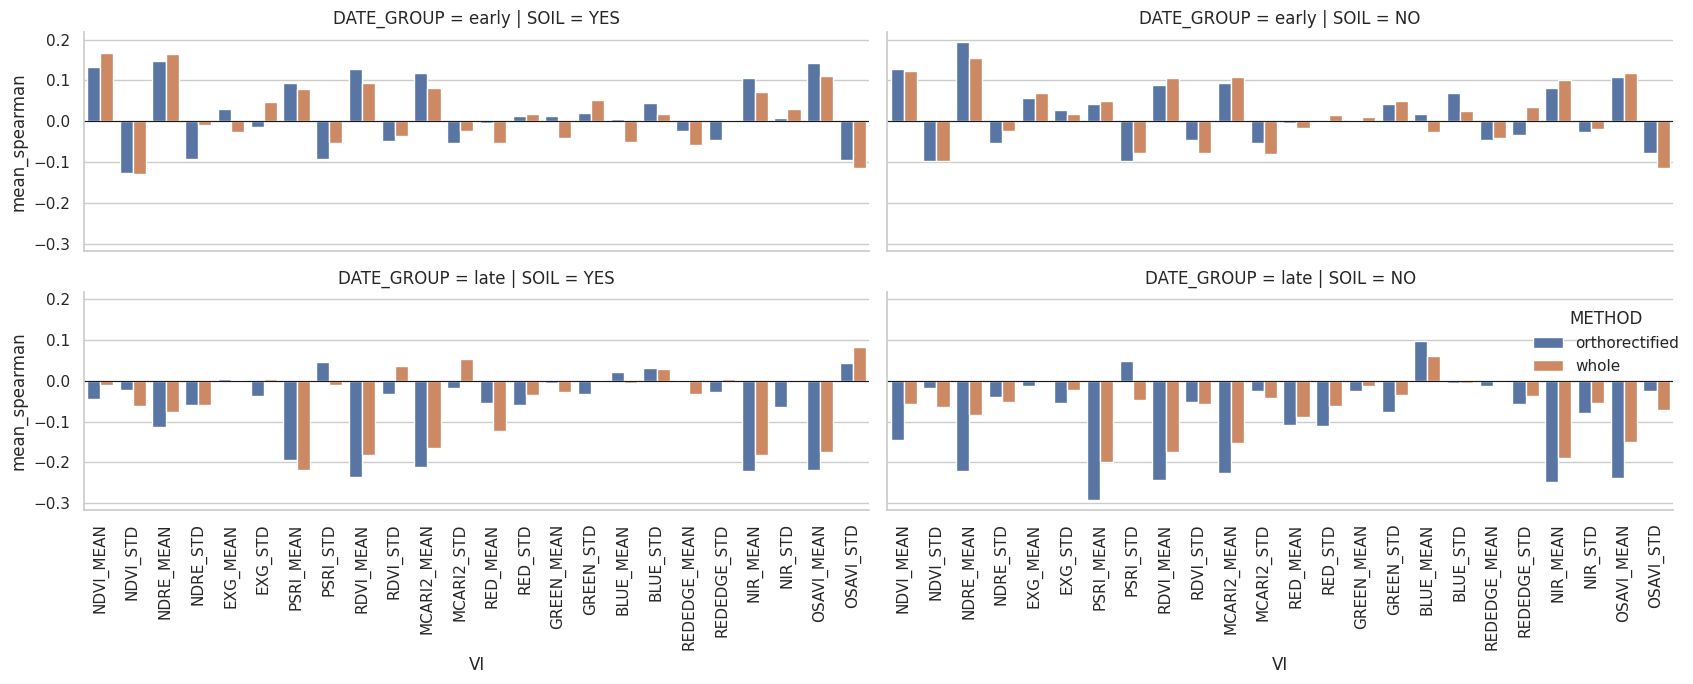

In [17]:
# Spearman correlation strength (VI vs SEVERITY) per date group, METHOD, SOIL
strat_spearman_rows = []
for (method, soil), _ in combo_data.items():
    sub_full = df_sev[(df_sev["METHOD"] == method) & (df_sev["SOIL"] == soil)]
    for group in ["early", "late"]:
        sub = sub_full[sub_full["DATE_GROUP"] == group]
        for vi in vi_mean_std_cols:
            rhos = []
            for _, g in sub.groupby("DATE"):
                r, _ = spearmanr(g[vi], g["SEVERITY"])
                rhos.append(r)
            z = np.arctanh(np.clip(rhos, -0.999, 0.999))
            mean_rho = np.tanh(np.nanmean(z))
            strat_spearman_rows.append({"METHOD": method, "SOIL": soil, "DATE_GROUP": group,
                                         "VI": vi, "mean_spearman": mean_rho})

strat_spearman_df = pd.DataFrame(strat_spearman_rows)

g = sns.catplot(
    data=strat_spearman_df, x="VI", y="mean_spearman", hue="METHOD",
    col="SOIL", row="DATE_GROUP", kind="bar", height=3.5, aspect=2.2,
)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=90)
    ax.axhline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()

In [18]:
# Predictive R2 within each date-group, METHOD, SOIL (GroupKFold(3) - fewer dates per group)
strat_cv = GroupKFold(n_splits=3)
strat_cv_rows = []

for (method, soil), _ in combo_data.items():
    sub_full = df_sev[(df_sev["METHOD"] == method) & (df_sev["SOIL"] == soil)]
    for group in ["early", "late"]:
        sub = sub_full[sub_full["DATE_GROUP"] == group]
        X = sub[vi_mean_std_cols].to_numpy()
        y = sub["SEVERITY"].to_numpy()
        groups_arr = sub["POINT"].to_numpy()

        for model_name, model in make_models().items():
            for fold_idx, (train_idx, test_idx) in enumerate(strat_cv.split(X, y, groups_arr)):
                m = clone(model)
                m.fit(X[train_idx], y[train_idx])
                pred = m.predict(X[test_idx]).ravel()
                strat_cv_rows.append({
                    "METHOD": method, "SOIL": soil, "DATE_GROUP": group, "MODEL": model_name,
                    "FOLD": fold_idx, "R2": r2_score(y[test_idx], pred),
                })

strat_cv_df = pd.DataFrame(strat_cv_rows)
strat_cv_df.groupby(["DATE_GROUP", "SOIL", "MODEL", "METHOD"])["R2"].agg(["mean", "std"])

mean       std
DATE_GROUP SOIL MODEL METHOD                            
early      NO   PLSR  orthorectified -0.001657  0.080955
                      whole           0.013979  0.122901
                RF    orthorectified -0.266773  0.330822
                      whole          -0.326259  0.554013
                Ridge orthorectified  0.006429  0.046675
                      whole           0.058043  0.054788
           YES  PLSR  orthorectified -0.012139  0.062771
                      whole           0.013623  0.126925
                RF    orthorectified -0.237610  0.311177
                      whole          -0.213178  0.215917
                Ridge orthorectified -0.004118  0.069567
                      whole           0.056824  0.046436
late       NO   PLSR  orthorectified  0.915351  0.026355
                      whole           0.895513  0.041171
                RF    orthorectified  0.947099  0.017892
                      whole           0.939313  0.014732
                Ridge orthorectified  0.950980  0.008832
                      whole           0.908054  0.065281
           YES  PLSR  orthorectified  0.926440  0.022100
                      whole           0.921445  0.023115
                RF    orthorectified  0.942377  0.009638
                      whole           0.941659  0.012928
                Ridge orthorectified  0.949483  0.012076
                      whole           0.949721  0.008359

**Note on "early" R2 values**: in the early-season window SEVERITY is essentially zero
for almost every plot (mean 0.0002, max 0.0056) — there is virtually no disease signal to
predict yet. Negative/near-zero R2 in this window is therefore expected (a model can't
beat predicting the near-constant mean) and should be read as "no detectable disease
signal pre-onset" rather than as a model failure. The "late" window, where severity has
real spread (mean 1.13, max 6.02), is where method differences in predictive power are
meaningful.

## Section 6 — Feature Importance Comparison

In [19]:
def vip_scores(pls):
    """Variable Importance in Projection for a fitted PLSRegression."""
    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_
    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    total_s = np.sum(s)
    vips = np.zeros(p)
    for i in range(p):
        weight = np.array([(w[i, j] / np.linalg.norm(w[:, j])) ** 2 for j in range(h)])
        vips[i] = np.sqrt(p * float(s.T @ weight) / total_s)
    return vips


importance_rows = []
for (method, soil) in combo_data:
    rf_models = fitted_models[(method, soil, "RF")]
    rf_imp = np.mean([m.feature_importances_ for m in rf_models], axis=0)
    rf_imp_std = np.std([m.feature_importances_ for m in rf_models], axis=0)

    pls_models = fitted_models[(method, soil, "PLSR")]
    pls_vip = np.mean([vip_scores(m.named_steps["pls"]) for m in pls_models], axis=0)

    for i, vi in enumerate(vi_mean_std_cols):
        importance_rows.append({
            "METHOD": method, "SOIL": soil, "VI": vi,
            "RF_importance": rf_imp[i], "RF_importance_std": rf_imp_std[i],
            "PLSR_VIP": pls_vip[i],
        })

importance_df = pd.DataFrame(importance_rows)
importance_df.head()

/tmp/ipykernel_91268/3037622922.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vips[i] = np.sqrt(p * float(s.T @ weight) / total_s)
/tmp/ipykernel_91268/3037622922.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vips[i] = np.sqrt(p * float(s.T @ weight) / total_s)
/tmp/ipykernel_91268/3037622922.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vips[i] = np.sqrt(p * float(s.T @ weight) / total_s)
/tmp/ipykernel_91268/3037622922.py:12: DeprecationWarni

,METHOD,SOIL,VI,RF_importance,RF_importance_std,PLSR_VIP
0,orthorectified,YES,NDVI_MEAN,0.060044,0.042795,0.526478
1,orthorectified,YES,NDVI_STD,0.003656,0.000974,0.489633
2,orthorectified,YES,NDRE_MEAN,0.025545,0.003769,0.797058
3,orthorectified,YES,NDRE_STD,0.006105,0.004480,0.985032
4,orthorectified,YES,EXG_MEAN,0.011011,0.014346,0.665418


In [20]:
# Rank agreement between orthorectified and whole (within each SOIL)
rank_rows = []
for soil in soils:
    for score_col in ["RF_importance", "PLSR_VIP"]:
        pivot = importance_df[importance_df["SOIL"] == soil].pivot(index="VI", columns="METHOD", values=score_col)
        rho, p = spearmanr(pivot["orthorectified"], pivot["whole"])
        rank_rows.append({"SOIL": soil, "SCORE": score_col, "rank_spearman_rho": rho, "p_value": p})

pd.DataFrame(rank_rows)

,SOIL,SCORE,rank_spearman_rho,p_value
0,YES,RF_importance,0.837391,3.343844e-07
1,YES,PLSR_VIP,0.875652,2.107683e-08
2,NO,RF_importance,0.807826,1.814056e-06
3,NO,PLSR_VIP,0.448696,2.786004e-02


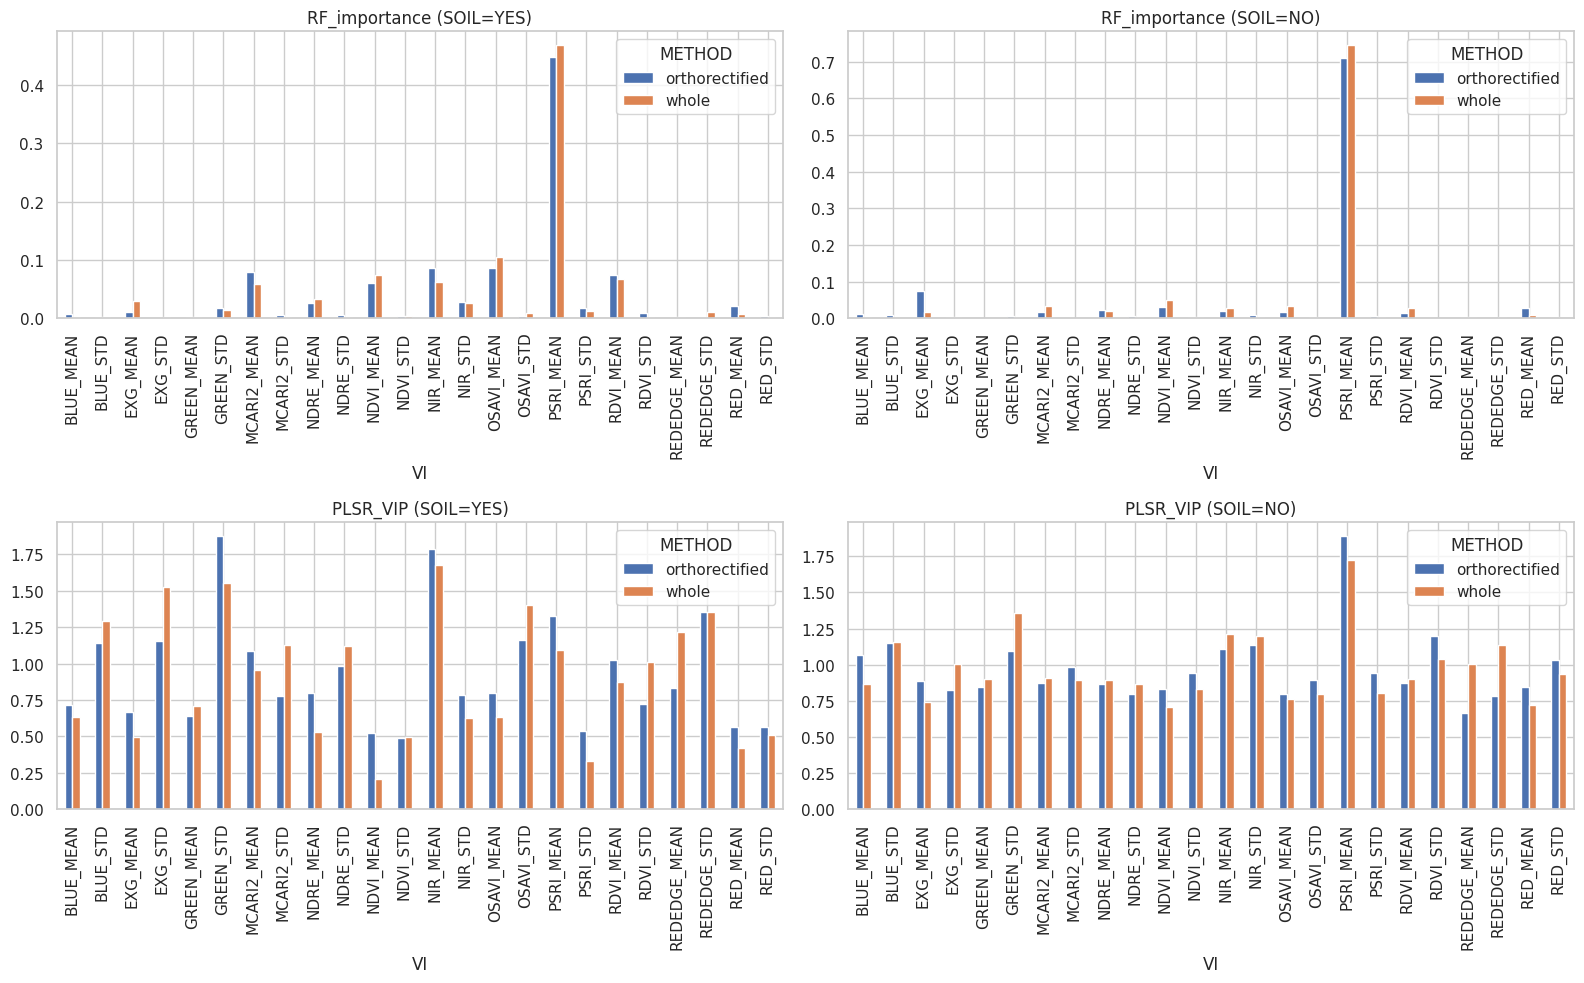

In [21]:
# Side-by-side bar charts: RF importance and PLSR VIP, orthorectified vs whole, per SOIL
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for row, score_col in enumerate(["RF_importance", "PLSR_VIP"]):
    for col, soil in enumerate(soils):
        ax = axes[row, col]
        sub = importance_df[importance_df["SOIL"] == soil]
        plot_df = sub.pivot(index="VI", columns="METHOD", values=score_col)
        plot_df.plot(kind="bar", ax=ax)
        ax.set_title(f"{score_col} (SOIL={soil})")
        ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()